### Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('dataset/0.01percent_2classes.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset Shape: (466657, 47)

First few rows:
   flow_duration  header_length protocol_type  duration  rate  srate  drate  \
0       0.000000             54           TCP     64.00    37     37    0.0   
1       0.000000             54           TCP     64.00    29     29    0.0   
2       0.000000             54           TCP     64.00     0      0    0.0   
3       0.048848             60           TCP     65.91     1      1    0.0   
4       0.555381         883353           UDP     64.00  2870   2870    0.0   

   fin_flag_number  syn_flag_number  rst_flag_number  ...       std  tot_size  \
0            False             True            False  ...  0.000000     54.00   
1             True            False             True  ...  0.000000     54.00   
2            False             True            False  ...  0.000000     54.00   
3            False             True            False  ...  2.532528     54.67   
4            False            False            False  ...  0.000000    554.

In [2]:
print("\nData types:")
print(df.dtypes)


Data types:
flow_duration      float64
header_length        int64
protocol_type          str
duration           float64
rate                 int64
srate                int64
drate              float64
fin_flag_number       bool
syn_flag_number       bool
rst_flag_number       bool
psh_flag_number       bool
ack_flag_number       bool
ece_flag_number       bool
cwr_flag_number       bool
ack_count          float64
syn_count          float64
fin_count            int64
urg_count            int64
rst_count            int64
http                  bool
https                 bool
dns                   bool
telnet                bool
smtp                  bool
ssh                   bool
irc                   bool
tcp                   bool
udp                   bool
dhcp                  bool
arp                   bool
icmp                  bool
ipv                   bool
llc                   bool
tot_sum            float64
min                float64
max                float64
avg            

In [3]:
print("\nMemory usage:")
print(df.memory_usage(deep=True))


Memory usage:
Index                   132
flow_duration       3733256
header_length       3733256
protocol_type      24431886
duration            3733256
rate                3733256
srate               3733256
drate               3733256
fin_flag_number      466657
syn_flag_number      466657
rst_flag_number      466657
psh_flag_number      466657
ack_flag_number      466657
ece_flag_number      466657
cwr_flag_number      466657
ack_count           3733256
syn_count           3733256
fin_count           3733256
urg_count           3733256
rst_count           3733256
http                 466657
https                466657
dns                  466657
telnet               466657
smtp                 466657
ssh                  466657
irc                  466657
tcp                  466657
udp                  466657
dhcp                 466657
arp                  466657
icmp                 466657
ipv                  466657
llc                  466657
tot_sum             3733256
min  

In [4]:
# Missing values
print("Missing values:")
print(df.isnull().sum())

# Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
flow_duration      0
header_length      0
protocol_type      0
duration           0
rate               0
srate              0
drate              0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
psh_flag_number    0
ack_flag_number    0
ece_flag_number    0
cwr_flag_number    0
ack_count          0
syn_count          0
fin_count          0
urg_count          0
rst_count          0
http               0
https              0
dns                0
telnet             0
smtp               0
ssh                0
irc                0
tcp                0
udp                0
dhcp               0
arp                0
icmp               0
ipv                0
llc                0
tot_sum            0
min                0
max                0
avg                0
std                0
tot_size           0
iat                0
number             0
radius             0
covariance         0
variance           0
weight             0
magnitude          0
benign            

In [5]:
# Data range
print("\nBasic statistics:")
print(df.describe())


Basic statistics:
       flow_duration  header_length       duration          rate  \
count  466657.000000   4.666570e+05  466657.000000  4.666570e+05   
mean        6.353503   7.607334e+04      66.319992  9.224124e+03   
std       350.804456   4.584149e+05      13.869932  1.018534e+05   
min         0.000000   0.000000e+00       0.000000  0.000000e+00   
25%         0.000000   5.400000e+01      64.000000  2.000000e+00   
50%         0.000000   5.400000e+01      64.000000  1.500000e+01   
75%         0.105600   2.700000e+02      64.000000  1.160000e+02   
max     93346.490000   9.806497e+06     255.000000  7.340032e+06   

              srate          drate      ack_count      syn_count  \
count  4.666570e+05  466657.000000  466657.000000  466657.000000   
mean   9.224124e+03       0.000002       0.090616       0.330020   
std    1.018534e+05       0.000717       0.286561       0.662282   
min    0.000000e+00       0.000000       0.000000       0.000000   
25%    2.000000e+00       0.

Class distribution:
benign
False    455673
True      10984
Name: count, dtype: int64

Class balance (%):
benign
False    97.646237
True      2.353763
Name: proportion, dtype: float64


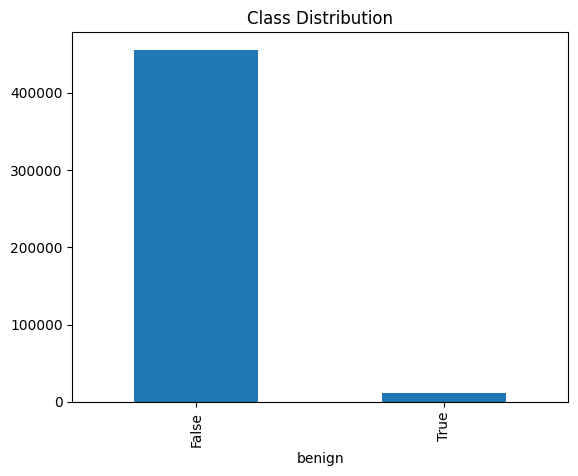

In [6]:
print("Class distribution:")
print(df['benign'].value_counts())
print("\nClass balance (%):")
print(df['benign'].value_counts(normalize=True) * 100)

# Imbalanced? 
import matplotlib.pyplot as plt
df['benign'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.show()

Categorical columns:
['protocol_type']
protocol_type
TCP                   243926
ICMP                   70908
UDP                    67518
CHAOS                  29039
ST                     19388
GRE                     7532
RSVP                    6091
HOPOPT                  4988
CBT                     3168
XNET                    2086
IDRP                    1954
EGP                     1929
IGP                     1374
EMCON                   1005
BBN-RCC-MON              958
ARGUS (deprecated)       735
PUP                      729
NVP-II                   714
IPv6-Frag                700
IPv4                     370
IGMP                     367
IPv6-Route               341
SDRP                     169
GGP                      146
IPv6                     117
IL                        89
TP++                      59
IDPR-CMTP                 45
DDP                       35
XTP                       27
IDPR                      26
DCCP                      19
3PC                

/tmp/ipykernel_1948080/1430472828.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns.tolist())


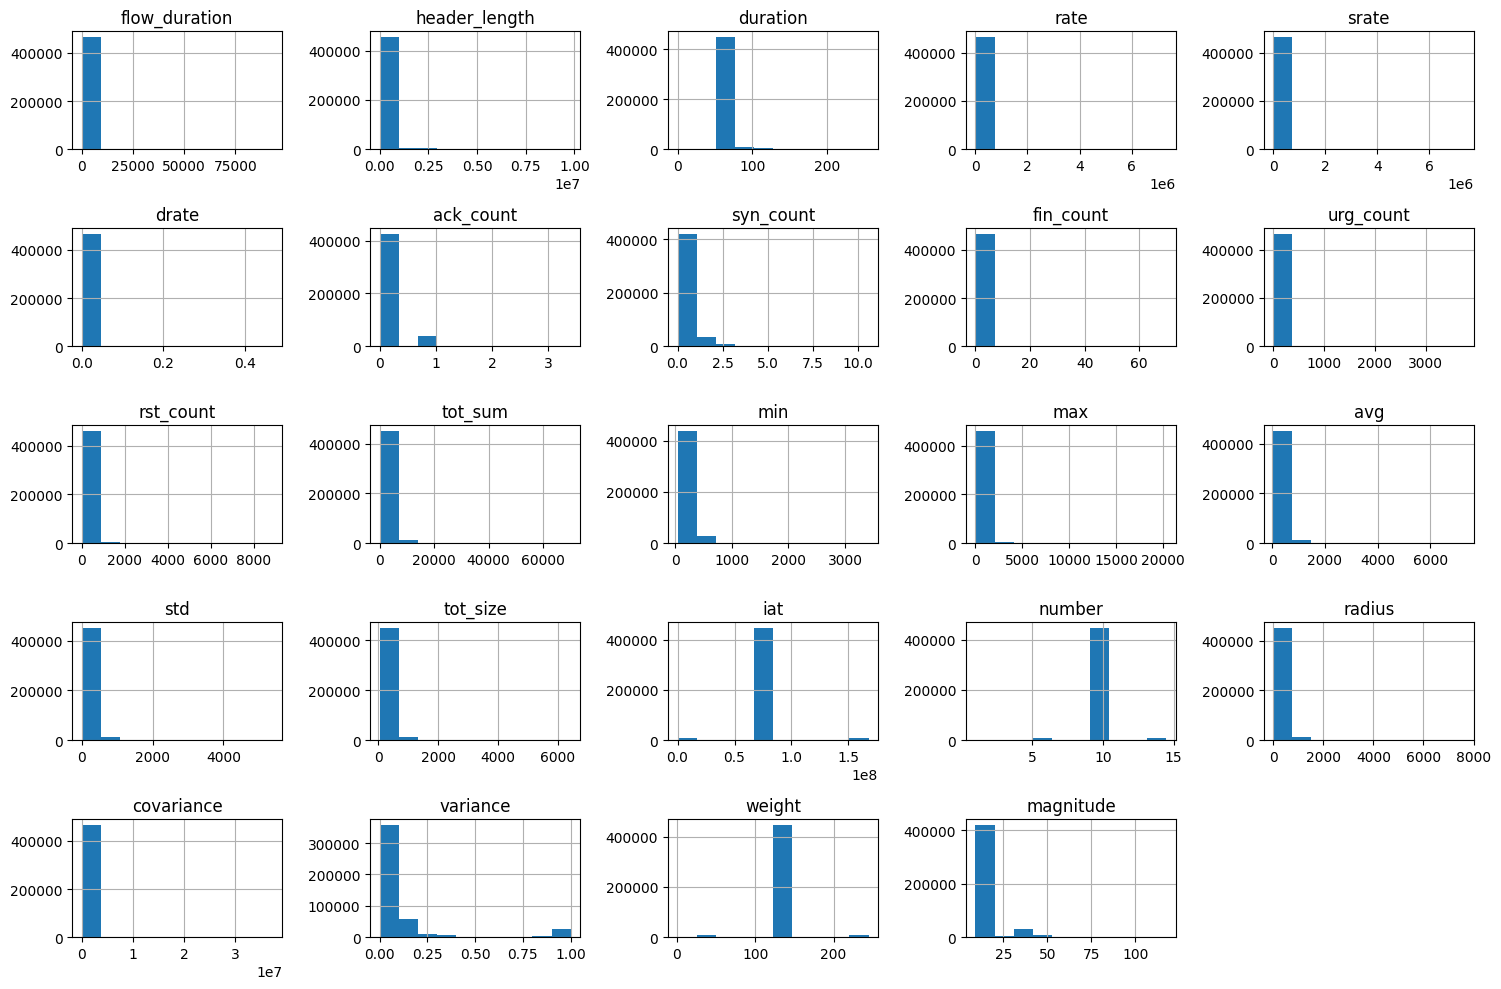

In [7]:
# Categorical columns
print("Categorical columns:")
print(df.select_dtypes(include='object').columns.tolist())

# Check unique values for categorical
print(df['protocol_type'].value_counts())

# Numeric features distribution
df.select_dtypes(include=[np.number]).hist(figsize=(15, 10))
plt.tight_layout()
plt.show()